# 목표 설명
각 이미지 조각에 대해, 분류기를 통해 학습을 시킨다.</br>
학습이 완료되면, 앞서 train 데이터에 적용한 방법을 사용하여 test 데이터를 생성한다.</br>
분류기를 통해, test 데이터의 이미지들에 대해 분류를 수행한다.

In [293]:
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from torchvision.datasets import ImageFolder
from torchvision.transforms import v2
from torch.utils.data import Dataset, DataLoader, Subset
from torch import optim
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import torch
import torch.nn as nn
import os
import gc
import math
import shutil
import random
import json
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import operator
import pandas as pd
import copy
from glob import glob

num_classes = 74

데이터는 앞서 전처리 파일을 통해 얻은 '객체 - 클래스 id' 매핑 파일을 활용하여 만든다.</br>
우선 이를 활용하여 데이터셋을 만들어주자.</br>
</br>
이번에 사용할 데이터는 다음과 같이 변환한 데이터를 반환한다.

1. 폴더 종류를 함께 저장하여, 추가 데이터 여부를 인덱스 번호에 따라 판단한다.
2. 폴더 종류에 맞춰서 이미지를 로드해온다.
3. ImageNet 데이터의 분포에 맞춰서 데이터에 대한 transform을 적용한다.
4. 데이터와 클래스 번호를 함께 반환한다.

이때, 클래스 번호는 원래의 번호 대신, 0~73으로 정수 인코딩한 값을 사용한다.

# 이미지 샘플링 후 저장하기
첫 단계는 이미지를 샘플링하고 저장하는 것이다.</br>
우선 이미지 수가 가장 적은 클래스를 구해야 한다.</br>
또한, 이미지들이 서로 다른 폴더로 나뉘어 있기 때문에 이들을 합쳐서 샘플링해줘야 한다.</br>
샘플링을 한 후에는 하나의 트리 구조로 샘플링 된 결과를 합쳐서 저장한다.

In [173]:
# 잘린 이미지들이 위치한 폴더
image_root='./additional_pill_images'
folders=sorted(os.listdir(image_root))
class_id=0
labelling_map={}
images_per_class={}
class_count={}
count=0
# 라벨링 파일
with open('./additional_label_mapping.txt','r') as f:
    f.readline()
    lines=f.readlines()
    for line in lines:
        line=line.strip().split('\t')
        if len(line)==2:
            class_id=int(line[1])
        labelling_map[line[0]]=(class_id,'additional')
        if class_id not in class_count.keys():
            class_count[class_id]=1
        else:
            class_count[class_id]+=1
        if class_id not in images_per_class.keys():
            images_per_class[class_id]=[]
        images_per_class[class_id].append(line[0])
        


with open('./label_mapping.txt','r') as f:
    f.readline()
    lines=f.readlines()
    for line in lines:
        line=line.strip().split('\t')
        if len(line)==2:
            class_id=int(line[1])
        labelling_map[line[0]]=(class_id,'original')
        if class_id not in class_count.keys():
            class_count[class_id]=1
        else:
            class_count[class_id]+=1
        if class_id not in images_per_class.keys():
            images_per_class[class_id]=[]
        images_per_class[class_id].append(line[0])

class_count

{10220: 348,
 10223: 381,
 12080: 368,
 12246: 364,
 12419: 376,
 12777: 468,
 13394: 359,
 13899: 279,
 16231: 856,
 16261: 632,
 16547: 1002,
 16550: 988,
 16687: 149,
 18109: 220,
 18146: 147,
 18356: 148,
 1899: 262,
 19231: 152,
 19551: 459,
 19606: 221,
 19860: 467,
 20013: 152,
 20237: 628,
 20876: 494,
 21025: 212,
 21324: 172,
 21770: 219,
 22073: 144,
 22346: 495,
 22361: 338,
 22626: 455,
 23202: 159,
 23222: 453,
 2482: 313,
 24849: 214,
 25366: 497,
 25437: 413,
 25468: 482,
 27652: 485,
 27732: 481,
 27776: 456,
 27925: 218,
 27992: 162,
 28762: 479,
 29344: 213,
 29450: 208,
 29666: 623,
 29870: 159,
 30307: 458,
 31704: 213,
 31862: 141,
 31884: 465,
 32309: 147,
 33008: 213,
 33207: 216,
 33877: 160,
 33879: 154,
 34596: 471,
 35205: 618,
 3543: 303,
 36636: 613,
 3742: 492,
 38161: 168,
 3831: 288,
 41767: 151,
 4377: 423,
 44198: 216,
 4542: 355,
 5093: 313,
 5885: 360,
 6191: 464,
 6562: 360,
 3350: 157,
 3482: 255}

혹시 모르니, 두 폴더 사이에 중복이 있는지 확인한다.

In [182]:
for c in class_count.keys():
    l1,l2=len(images_per_class[c]),len(set(images_per_class[c]))
    if l1!=l2:
        class_count[c]=l2
        print(l1,l2,c)
        images_per_class[c]=list(set(images_per_class[c]))

459 458 19551
213 212 31704
213 212 33008
154 152 33879


어째선지 중복이 있었고, 이들은 코드 단계에서 수정하였다.</br>
</br>
전체 클래스 중, 데이터 수가 가장 적은 클래스의 데이터 수도 확인한다.

In [188]:
min(class_count.values())

141

이 클래스에 맞춰서 이미지들을 undersampling해준다.</br>
python의 기본 random 라이브러리를 활용한다.

In [ ]:
def create_undersampled_dataset(class_images_map, dst_root='./train_images', class_count=class_count):
    os.makedirs(dst_root, exist_ok=True)
    random.seed(42)

    min_count=min(class_count.values())

    for cat in class_count.keys():
        src=class_images_map[cat]
        dst_dir = os.path.join(dst_root, str(cat))
        os.makedirs(dst_dir, exist_ok=True)

        images = copy.deepcopy(src)
        random.shuffle(images)

        selected = images[:min_count]

        for img in selected:
            src_key=labelling_map[img]
            if src_key[1]=='additional':
                src_path=os.path.join('./additional_pill_images',str(cat),img+'.png')
            else:
                src_path=os.path.join('./pill_images',str(cat),img+'.png')
            
            shutil.copy(src_path,os.path.join(dst_dir, img+'.png'))

        print(f"{cat}: {len(selected)}장 복사 완료")

In [190]:
create_undersampled_dataset(images_per_class)

10220: 141장 복사 완료
10223: 141장 복사 완료
12080: 141장 복사 완료
12246: 141장 복사 완료
12419: 141장 복사 완료
12777: 141장 복사 완료
13394: 141장 복사 완료
13899: 141장 복사 완료
16231: 141장 복사 완료
16261: 141장 복사 완료
16547: 141장 복사 완료
16550: 141장 복사 완료
16687: 141장 복사 완료
18109: 141장 복사 완료
18146: 141장 복사 완료
18356: 141장 복사 완료
1899: 141장 복사 완료
19231: 141장 복사 완료
19551: 141장 복사 완료
19606: 141장 복사 완료
19860: 141장 복사 완료
20013: 141장 복사 완료
20237: 141장 복사 완료
20876: 141장 복사 완료
21025: 141장 복사 완료
21324: 141장 복사 완료
21770: 141장 복사 완료
22073: 141장 복사 완료
22346: 141장 복사 완료
22361: 141장 복사 완료
22626: 141장 복사 완료
23202: 141장 복사 완료
23222: 141장 복사 완료
2482: 141장 복사 완료
24849: 141장 복사 완료
25366: 141장 복사 완료
25437: 141장 복사 완료
25468: 141장 복사 완료
27652: 141장 복사 완료
27732: 141장 복사 완료
27776: 141장 복사 완료
27925: 141장 복사 완료
27992: 141장 복사 완료
28762: 141장 복사 완료
29344: 141장 복사 완료
29450: 141장 복사 완료
29666: 141장 복사 완료
29870: 141장 복사 완료
30307: 141장 복사 완료
31704: 141장 복사 완료
31862: 141장 복사 완료
31884: 141장 복사 완료
32309: 141장 복사 완료
33008: 141장 복사 완료
33207: 141장 복사 완료
33877: 141장 

# Dataset 및 DataLoader 만들기
이제 생성된 이미지를 ImageFolder를 사용하여 torch의 Dataset으로 만들 수 있다.</br>
먼저 클래스 별로 학습 데이터와 검증 데이터로 나눠준다.</br>
각각 141장이므로, sklearn의 train_test_split으로 비율 기준 분할을 한다.</br>
비율로는 0.8:0.2로 수행하겠다.</br>
인덱스 기준으로 나누고, 나뉜 결과를 모든 클래스에 일괄적으로 적용한다.

In [191]:
folders=sorted(os.listdir('./train_images'))

In [192]:
for folder in folders:
    if len(os.listdir(os.path.join('./train_images',folder)))<141:
        print(folder)

이제 Dataset을 만든다.

In [195]:
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

transform = v2.Compose([
    v2.Resize((224, 224)),
    v2.ToTensor(),
    v2.Normalize(mean=imagenet_mean, std=imagenet_std)
])

dataset=ImageFolder("./train_images", transform=transform)

/home/codeitDev/miniconda3/envs/codeit/lib/python3.11/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


총 이미지 수는 141*74개이다.</br>
모든 클래스에 대해 동일한 샘플링 결과를 사용하여 학습 데이터를 추출한다고 가정한다.</br>
즉, 141개의 index에 대한 샘플링을 하고 그 결과를 반복적으로 사용하여 train_idx와 val_idx를 만든다.

In [ ]:
idx=list(range(141))
train_idx_b,val_idx_b=train_test_split(idx,test_size=0.2,random_state=42)
train_idx_b,val_idx_b=np.array(train_idx_b,dtype=int),np.array(val_idx_b,dtype=int)
train_idx,val_idx=np.array([],dtype=int),np.array([],dtype=int)
for i in range(74):
    train_idx=np.concatenate([train_idx,(train_idx_b+i*141)])
    val_idx=np.concatenate([val_idx,(val_idx_b+i*141)])

추후, loss 계산에 사용하기 위해 데이터 수를 구한다.

In [216]:
len(train_idx),len(val_idx)

(8288, 2146)

In [308]:
train_split_dataset=Subset(dataset,train_idx)
val_dataset=Subset(dataset,val_idx)

train_dataset은 추가로 증강을 더할 것이다.</br>
이를 위해 아래와 같은 transform을 추가한다.

In [325]:
augmentation_transform=v2.Compose([
    v2.RandomRotation(degrees=45,expand=True,fill=130),
    v2.Resize((224, 224))
])

In [326]:
class TrainDataset(Dataset):
    def __init__(self,dataset,transform):
        self.dataset=dataset
        self.transform=transform
    
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self,idx):
        img,label=self.dataset[idx]
        return self.transform(img),label

In [327]:
train_dataset=TrainDataset(train_split_dataset,augmentation_transform)

이제 DataLoader를 만들어준다.</br>
이미지 데이터 특성 상, 배치 크기는 8 내외가 적당하다고 생각하였다.

In [328]:
val_loader=DataLoader(val_dataset,8,shuffle=False,num_workers=2)

# 모델 로드 및 학습
다음으로는 모델을 로드한다.</br>
여기서는 EfficientNet을 사용한다.

In [329]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("현재 장치:", device)

현재 장치: cuda


In [349]:
# 가중치 로드
model = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)

# 출력 개수 변경
in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, num_classes)

model=model.to(device)

In [350]:
gc.collect()
torch.cuda.empty_cache()

사전 학습 모델을 활용하지만, 완전히 새로운 데이터이므로 전체 모델을 학습한다.</br>
학습 파라미터는 아래와 같다.

In [351]:
warmup_epochs = 5
total_epochs = 200

def lr_lambda(epoch):
    if epoch < warmup_epochs:
        return float(epoch) / float(max(1, warmup_epochs))
    return 0.5 * (1 + math.cos(math.pi * (epoch - warmup_epochs) / (total_epochs - warmup_epochs)))

In [352]:
params=params = [p for p in model.parameters() if p.requires_grad]
optimizer = optim.Adam(params, lr=5e-5, weight_decay=0.0005)

lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.1,
    patience=5
)

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
scaler = torch.amp.GradScaler('cuda')
criterion = nn.CrossEntropyLoss()
best_val_loss=float('inf')
train_losses=[]
val_losses=[]

In [ ]:
early_count=0
np.random.seed(42)
seeds=np.random.randint(0, 10_000_000, size=200).tolist()
for epoch in range(200):
    g=torch.Generator()
    g.manual_seed(seeds[epoch])
    model.train()
    train_loader=DataLoader(train_dataset,2,shuffle=True,generator=g)
    train_loss=0

    for images,labels in tqdm(train_loader,desc=f'Epoch {epoch+1} Train Loop'):
        images=images.to(device)
        labels=labels.to(device)

        optimizer.zero_grad()
        with torch.amp.autocast('cuda',torch.bfloat16):
            outputs=model(images)
            loss=criterion(outputs,labels)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        train_loss += loss.item()*len(labels)

    val_loss=0
    correct = 0
    total = 0

    model.eval()
    with torch.no_grad():
        for images,labels in tqdm(val_loader, desc=f'Epoch {epoch+1} Val Loop'):
            images = images.to(device)
            labels = labels.to(device)

            total+=len(labels)
            
            with torch.amp.autocast('cuda',torch.bfloat16):
                outputs = model(images)
                loss = criterion(outputs, labels)
            
                preds = outputs.argmax(dim=1)
                correct += (preds == labels).sum().item()

            val_loss += loss.item()*len(labels)

    train_loss=train_loss/len(train_dataset)
    val_loss=val_loss/len(val_dataset)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    # 최고 성적 갱신 시 모델을 저장
    if best_val_loss>val_loss:
        best_val_loss=val_loss
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scaler_state_dict': scaler.state_dict(),  # AMP 사용 시 GradScaler 상태도 저장
            'best_val_loss': best_val_loss,
        }, f"Classifier_v2_best.pth")
        print('New Best!')
        early_count=0
    else:
        early_count+=1

    print(f'epoch {epoch+1}')
    print(f'Train Loss: {train_loss:.5f}, Val Loss: {val_loss:.5f}')
    print(f'Val accuracy: {(correct/total):.4f}')

    # lr_scheduler.step(val_loss)
    scheduler.step()
    
    gc.collect()
    torch.cuda.empty_cache()

    if early_count==20:
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scaler_state_dict': scaler.state_dict(),  # AMP 사용 시 GradScaler 상태도 저장
            'best_val_loss': best_val_loss,
        }, f"Classifier_v2_last.pth")
        break

Epoch 1 Train Loop:   0%|          | 0/4144 [00:00<?, ?it/s]

Epoch 1 Train Loop:   2%|▏         | 69/4144 [00:10<09:52,  6.88it/s]

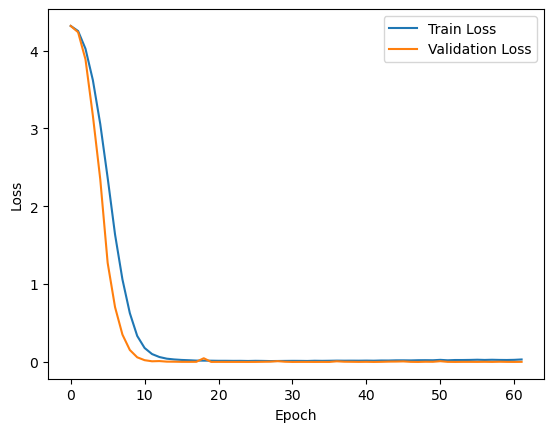

In [261]:
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# 테스트 데이터셋 만들기
이제 테스트 데이터를 만들 차례이다.</br>
테스트 데이터에 대해서는 아직 전처리를 하지 않았기 때문이다.</br>
</br>
여기서는 이미 배경을 지웠다는 가정 하에, bbox 검출 후 객체 단위로 나누는 작업을 먼저 수행한다.</br>
이 과정에서, 원래의 이미지 아이디와 매핑이 가능하도록 이름을 지정하고, bbox 파일도 '이미지 단위'로 작성한다.

In [264]:
def PIL2OpenCV(pil_image):
    numpy_image= np.array(pil_image)
    opencv_image = cv2.cvtColor(numpy_image, cv2.COLOR_RGB2BGR)
    return opencv_image

def OpenCV2PIL(opencv_image):
    color_coverted = cv2.cvtColor(opencv_image, cv2.COLOR_BGR2RGB)
    pil_image = Image.fromarray(color_coverted)
    return pil_image

In [265]:
def contour_center(cnt):
    M = cv2.moments(cnt)
    if M["m00"] == 0:
        return None
    cx = int(M["m10"] / M["m00"])
    cy = int(M["m01"] / M["m00"])
    return (cx, cy)

In [266]:
def sort_contours_TL_TR_BL_BR(contours, median_y):
    centers = [(contour_center(c), c) for c in contours]
    centers = [c for c in centers if c[0] is not None]

    # 1) y 기준 전체 정렬
    centers.sort(key=lambda x: x[0][1])

    # 2) 상단/하단 분리
    ys = [c[0][1] for c in centers]

    top = [c for c in centers if c[0][1] <= median_y]
    bottom = [c for c in centers if c[0][1] > median_y]

    # 3) 상단은 x 오름차순 → TL, TR
    top.sort(key=lambda x: x[0][0])

    bottom.sort(key=lambda x: x[0][0])

    sorted_contours = [c[1] for c in top + bottom]
    return sorted_contours

In [ ]:
images_path='./ai06-level1-project/test_cleaned'
annotations_path='./ai06-level1-project/test_bbox'

images=sorted(os.listdir(images_path))

os.makedirs(annotations_path,exist_ok=True)

count=0
for image in images:
    count+=1
    print(count)
    # 알약 조합은 이름에서 확장자 및 이미지 정보를 제거한 것과 같다.
    name=image[:-23]

    # 이미지 파일을 불러온다.
    image_file=Image.open(os.path.join(images_path,image))

    # 이미지 파일을 cv 파일로, 배경을 유지하여 만들어준다.
    image_cv=cv2.cvtColor(np.array(image_file), cv2.COLOR_RGBA2BGRA)

    # 이미지 파일을 cv 파일로, 배경을 지워서 만들어준다.
    image_file=PIL2OpenCV(image_file.convert("RGB"))

    # 이미지 파일 원본의 크기를 구한다.
    H,W,C=image_file.shape

    # 이미지 파일에 변형을 가할 파일을 만들어준다.
    conv_file=np.zeros_like(image_file)

    # 각 칸에 대해, 배경에 해당하면 흰색, 아니면 검은 색으로 만들어준다.
    conv_file[(image_file==[130,130,130]).all(axis=2)]=255
    
    # 흑백 반전을 취한다. (openCV의 마스크는 흑색이 배경, 백색을 객체로 인식함)
    conv_file=cv2.bitwise_not(conv_file)

    # 흑백 이미지(단일 채널)로 만들어준다.
    conv_file=cv2.cvtColor(conv_file, cv2.COLOR_BGR2GRAY)

    # 객체들의 경계선을 구한다.
    contours, _ = cv2.findContours(conv_file,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
    
    contours=sort_contours_TL_TR_BL_BR(contours,(H//2))

    # bbox들을 구한다.
    with open(os.path.join(annotations_path,image[:-4]+'_bbox.txt'),'w') as f:
        f.write('value order: x, y, w, h\n')
        idx=1
        for cnt in contours:
            x, y, w, h = cv2.boundingRect(cnt)
            if w<50 or h<50:
                continue
            cv2.rectangle(image_cv, (x,y), (x+w,y+h), (0, 256, 0), 2)
            f.write(f'image{idx}: {x},{y},{w},{h}\n')
            idx+=1

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
277


그 뒤에, 각 이미지를 잘라서 앞서 지정한 'cropped_test_images' 폴더에 넣어준다.

In [275]:
annotation_root='./ai06-level1-project/test_bbox'
image_root='./ai06-level1-project/test_cleaned'
crop_path='./cropped_test_images/'
# 각 이미지 정보 폴더를 순회한다.

annotations=sorted(os.listdir(annotation_root))
os.makedirs(crop_path, exist_ok=True)
cnt=0


# txt 파일들 목록을 불러온다.
image_info=copy.deepcopy([entry.name for entry in os.scandir(annotation_root) if entry.is_file() and entry.name.endswith(".txt")])
print(image_info)
# 이미지 하나에 대한 txt 파일마다
for sub_info in image_info:
    print(cnt+1)
    cnt+=1
    
    image_name=sub_info[:-4]
    # 이미지 이름은 sub_info에서 마지막 확장자를 지운 것과 같다.
    image=Image.open(os.path.join(image_root,image_name[:-5]+'.png'))

    # 이미지 파일을 cv 파일로, 배경을 유지하여 만들어준다.
    image_cv=cv2.cvtColor(np.array(image), cv2.COLOR_RGBA2BGRA)

    # 이미지 파일을 cv 파일로, 배경을 지워서 만들어준다.
    image_file=PIL2OpenCV(image.convert("RGB"))

    # 이미지 파일 원본의 크기를 구한다.
    H,W,C=image_file.shape

    with open(os.path.join(annotation_root,sub_info),'r') as f:
        f.readline()
        # 이미지의 높이, 너비 정보를 얻는다.
        parts=f.readlines()
        
        # 각 세부 이미지마다
        for part in parts:
            part=part.strip().split()
            # id와 좌표를 얻는다.
            part_id=part[0][5:-1]
            x,y,w,h=map(int,part[1].split(','))
            #cv2.rectangle(image_cv, (x,y), (x+w,y+h), (0, 256, 0), 2)
            # 배경을 유지한 이미지에서 세부 이미지를 잘라낸다.
            img=image_cv[y:y+h,x:x+w]
            img=Image.fromarray(cv2.cvtColor(img, cv2.COLOR_BGRA2RGBA))
            
            # 크기 640x640의 투명 배경인 빈 이미지를 만든다.
            canvas_size = (640,640)
            canvas = Image.new("RGBA", canvas_size, (0,0,0,0))
            x_=(640-w)//2
            y_=(640-h)//2
            canvas.paste(img,(x_,y_),img)
            canvas.save(os.path.join(crop_path,image_name[:-4]+part_id+'.png'))
'''fig, ax = plt.subplots(1, figsize=(12,9))
plt.imshow(canvas)
plt.show()'''

['1003_bbox.txt', '1004_bbox.txt', '1005_bbox.txt', '1006_bbox.txt', '1007_bbox.txt', '1009_bbox.txt', '100_bbox.txt', '1010_bbox.txt', '1012_bbox.txt', '1013_bbox.txt', '1014_bbox.txt', '1015_bbox.txt', '1016_bbox.txt', '1018_bbox.txt', '1019_bbox.txt', '1020_bbox.txt', '1022_bbox.txt', '1023_bbox.txt', '1025_bbox.txt', '1026_bbox.txt', '1027_bbox.txt', '1028_bbox.txt', '1029_bbox.txt', '102_bbox.txt', '1030_bbox.txt', '1034_bbox.txt', '1039_bbox.txt', '1041_bbox.txt', '1043_bbox.txt', '1044_bbox.txt', '1045_bbox.txt', '1046_bbox.txt', '1047_bbox.txt', '104_bbox.txt', '1050_bbox.txt', '1051_bbox.txt', '1053_bbox.txt', '1055_bbox.txt', '1056_bbox.txt', '1057_bbox.txt', '1058_bbox.txt', '1060_bbox.txt', '1064_bbox.txt', '1065_bbox.txt', '1067_bbox.txt', '1069_bbox.txt', '1070_bbox.txt', '1073_bbox.txt', '1075_bbox.txt', '1076_bbox.txt', '1077_bbox.txt', '1079_bbox.txt', '1080_bbox.txt', '1081_bbox.txt', '1085_bbox.txt', '1087_bbox.txt', '1089_bbox.txt', '108_bbox.txt', '1092_bbox.txt', 

'fig, ax = plt.subplots(1, figsize=(12,9))\nplt.imshow(canvas)\nplt.show()'

전처리가 완료된 테스트 이미지(예측 후 결과를 제출할 이미지)들을 test_dataset으로 만들어서 test_loader에 넣어준다.</br>
이를 활용하여 예측 결과를 만든 뒤, dictionary에 객체 단위의 예측 결과를 넣어준다.

In [284]:
class TestDataset(Dataset):
    def __init__(self,src,transform):
        self.root=src
        self.images=os.listdir(self.root)
        self.transform=transform
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self,idx):
        img=os.path.join(self.root,self.images[idx])
        img=self.transform(Image.open(img).convert("RGB"))
        return img,self.images[idx]

In [285]:
test_dataset=TestDataset('./cropped_test_images',transform)

In [286]:
test_dataset[0][1]

'1003_1.png'

제대로 사진 별 이름도 반환되는 것을 확인하였다.</br>
추가로, 예측의 클래스에 해당하는 값은 dataset.classes에서 등장하는 순서와 같다.</br>
즉, 클래스를 2로 예측했다면 'dataset.classes[2]'의 값으로 반환한 것이다.</br>
</br>
이제 test_loader를 만든 뒤, 예측을 수행해보자.

In [287]:
test_loader=DataLoader(test_dataset,8,shuffle=False,num_workers=2)

# 테스트 예측하기
모델에 넣고 예측 값을 출력하는 단계이다.</br>
우선 이미지 별 예측을 만들고, dictionary로 저장하자.

In [288]:
predict={}
model.eval()
with torch.no_grad():
    for imgs, names in test_loader:
        imgs = imgs.to(device, non_blocking=True)
        with torch.amp.autocast('cuda',torch.bfloat16):
            outputs = model(imgs)
        for o in range(len(names)):
            res=dataset.classes[torch.argmax(outputs[o])]
            predict[names[o]]=res
predict

{'1003_1.png': '34596',
 '1003_2.png': '16231',
 '1003_3.png': '27732',
 '1003_4.png': '3482',
 '1004_1.png': '3482',
 '1004_2.png': '27732',
 '1004_3.png': '16231',
 '1004_4.png': '34596',
 '1005_1.png': '34596',
 '1005_2.png': '16231',
 '1005_3.png': '27732',
 '1005_4.png': '3482',
 '1006_1.png': '25366',
 '1006_2.png': '20237',
 '1006_3.png': '25468',
 '1006_4.png': '3482',
 '1007_1.png': '25366',
 '1007_2.png': '20237',
 '1007_3.png': '25468',
 '1007_4.png': '3482',
 '1009_1.png': '22346',
 '1009_2.png': '16261',
 '1009_3.png': '25468',
 '1009_4.png': '3482',
 '100_1.png': '1899',
 '100_2.png': '16547',
 '100_3.png': '18109',
 '100_4.png': '33008',
 '1010_1.png': '22346',
 '1010_2.png': '16261',
 '1010_3.png': '25468',
 '1010_4.png': '3482',
 '1012_1.png': '1899',
 '1012_2.png': '16547',
 '1012_3.png': '24849',
 '1012_4.png': '27925',
 '1013_1.png': '27925',
 '1013_2.png': '24849',
 '1013_3.png': '16547',
 '1013_4.png': '1899',
 '1014_1.png': '1899',
 '1014_2.png': '16547',
 '1014_

# 제출 파일 만들기
앞서 획득한 bbox 파일들과 예제 파일들을 활용하여 제출 파일을 만든다.

In [307]:
OUTPUT_CSV = "./submission.csv"

rows = []
annotation_id = 1

txt_files = glob(os.path.join('./ai06-level1-project/test_bbox', "*.txt"))

# 각 bbox 정보 파일에 대해서
for txt_path in txt_files:
    # 대응하는 이미지 이름을 구한다.
    imgname = os.path.basename(txt_path)[:-9]
    
    # bbox 정보 파일을 읽는다.
    with open(txt_path, "r") as f:
        # 첫 줄은 인덱스니까 무시한다.
        f.readline()
        # 두 번째 줄부터의 값을 사용한다.
        lines = f.readlines()

        for idx,line in enumerate(lines):
            line=line.strip().split()
            x, y, w, h = map(int, line[1].split(','))
            img_fullname=imgname+f'_{idx+1}.png'

            cat=predict[img_fullname]

            rows.append({
                "annotation_id": annotation_id,
                "image_id": int(imgname),
                "category_id": int(cat),
                "bbox_x": x,
                "bbox_y": y,
                "bbox_w": w,
                "bbox_h": h,
                "score": 0.99
            })

            annotation_id += 1
df = pd.DataFrame(rows)
df.to_csv(OUTPUT_CSV, index=False)
print("CSV saved:", OUTPUT_CSV)

CSV saved: ./submission.csv
